Script evaluating the robustness of ResNet models to translation transformations, by comparing a retinotopic version and a Cartesian version of the network. 

The translation is applied via an 11×11 fixation point using a roll operation, ensuring that only the position of the pixels changes while preserving the content of the image (no cropping). We test:

    The average accuracy of the network on a given dataset after applying different translations to all the images.
    The impact of translation on each image for a given label, by identifying the translations that maximise or minimise the model's confidence in its prediction.
    The differences in behaviour between the retinotopic and Cartesian versions of the network, to assess their respective sensitivity to spatial displacements.

The analysis is conducted in the form of average maps, visualizing how translation affects accuracy and prediction variations across different regions of the image space. 

The results are saved as Parquet files for further exploration.

In [1]:
from retinotopy import *
welcome()

-----------------------------------------------------------------------------------------
On date 2025-01-05, Running learning on host obiwan.local with device mps, pytorch==2.6.0
-----------------------------------------------------------------------------------------
Welcome on macOS-15.3.1-arm64-arm-64bit


In [2]:
data_set_types = ['raw', 'bbox', 'full']

In [ ]:
def get_map_translate( map, i_image):
    map /= i_image
    map = np.array(map.cpu())
    return map

In [ ]:
args = Params()
im_zero = ((args.resolution[0]*args.resolution[1])//2)
args.do_translate = True
args.do_resize = True
for data_set_type in data_set_types: 
    print(50*'=') 
    print(f'{data_set_type=}', end=', ')    
    args.do_mask = False
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type if data_set_type != 'raw' else 'full'}' # Directory containing images
    args.folders = ['val'] # type of images to use

    for model_name in  ['resnet101'] : #, 
        print(f'{model_name=}', end=', ')

        for do_polar in [True, False]:
            do_polar = do_polar if data_set_type != 'raw' else False
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            attack_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_translate_acc.parquet'
            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_translate_accuracy_acc.parquet'
            if os.path.isfile(df_filename_acc):
                print(f'>> Reading {df_filename_acc=}')
                df_translate = pd.read_parquet(df_filename_acc)
            else:
                df_mean, df_attack = None, None
                print(f'>> Computing {df_filename_acc=}')

                image_dataset = image_datasets_transforms(args)['val']

                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt' if data_set_type != 'raw' else None

                print(f"Loading pre-trained resnet {model_filename}")
                model = load_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
            
                pprint(f'Testing : {model_name}')

                model = model.eval()

                pred_translate = torch.zeros(args.resolution[0]*args.resolution[1])
                with torch.no_grad():
                    for i_image, (data, label) in tqdm(enumerate(image_dataset)) : 
                        label_batch = (torch.ones([len(data)])*label).data
                        data = data.to(device)
                
                        outputs = model(data)
                
                        outputs = torch.softmax(outputs, dim=1)
                
                        prior_outputs = outputs[:,label]
                        
                        argmax = torch.argmax(prior_outputs) 
                        argmin = torch.argmin(prior_outputs) 
                
                        _, preds = torch.max(outputs.data.cpu(), dim=1)

                        avg_acc = ((preds == torch.ones([len(data)])*label)*1.).cpu()

                        pred_translate += avg_acc.cpu()

                        
                        df_attack_ = pd.DataFrame({'likelihood_0':[prior_outputs[im_zero].item()], '0_pred':torch.argmax(outputs[im_zero]).item(), 
                                            'likelihood_max':prior_outputs[argmax].item(), 'max_pos':argmax.item(), 'max_pred':torch.argmax(outputs[argmax]).item(), 
                                            'likelihood_min':prior_outputs[argmin].item(), 'min_pos':argmin.item(), 'min_pred':torch.argmax(outputs[argmin]).item(),
                                            'i_image':i_image, 'filename':image_dataset.imgs[i_image][0], 'label':label})
                        
                        df_attack = store_pandas(df_attack, df_attack_)
                        if torch.cuda.is_available(): torch.cuda.empty_cache()   
                    
                    
                    df_mean_ = pd.DataFrame({'mean_accuracy':[get_map_translate(args, pred_translate, (i_image+1))]})
                    df_mean = store_pandas(df_mean, df_mean_)
                    model.cpu()
                    df_mean.to_parquet(df_filename_acc)
                    df_attack.to_parquet(attack_filename)

data_set_type='raw', model_name='resnet101', args.do_polar=False
..................................................
>> Reading df_filename_acc='cached_data/2025-01-05_raw_resnet101_cartesian_results_translate_accuracy_acc.parquet'
args.do_polar=False
..................................................
>> Reading df_filename_acc='cached_data/2025-01-05_raw_resnet101_cartesian_results_translate_accuracy_acc.parquet'
data_set_type='bbox', model_name='resnet101', args.do_polar=True
..................................................
>> Reading df_filename_acc='cached_data/2025-01-05_bbox_resnet101_retino_results_translate_accuracy_acc.parquet'
args.do_polar=False
..................................................
>> Reading df_filename_acc='cached_data/2025-01-05_bbox_resnet101_cartesian_results_translate_accuracy_acc.parquet'
data_set_type='full', model_name='resnet101', args.do_polar=True
..................................................
>> Reading df_filename_acc='cached_data/2025-01-05_

In [ ]:
#Translation attack read out
acc_plot = {}
for model_name in  ['resnet18', 'resnet50', 'resnet101']:
    print(50*'=')
    print(f'{model_name=}')
    for data_set_type, ls in zip(data_set_types, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_translate_acc.parquet'
            

            if os.path.isfile(df_filename_acc):

                df_translate = pd.read_parquet(df_filename_acc)
                print(do_polar)
                min = accuracy_score(df_translate['min_pred'], df_translate["label"])
                print(min, 'min_pred')
                zero = accuracy_score(df_translate['0_pred'], df_translate["label"])
                print(zero, 'zero')
                max_acc = accuracy_score(df_translate['max_pred'], df_translate["label"])
                print(max_acc, 'max_pred')
                print(zero-min, 'delta1', max_acc-zero, 'delta2')

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_min'] = min

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_zero'] = zero


model_name='resnet18'
data_set_type='raw'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
model_name='resnet50'
data_set_type='raw'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
model_name='resnet101'
data_set_type='raw'
--------------------------------------------------
False
0.5591535492129528 min_pred
0.7994679680780847 zero
0.9000740044402664 max_pred
0.24031441886513194 delta1 0.10060603636218168 delta2
data_set_type='bbox'
--------------------------------------------------
True
0.08729202132286243 min_pred
0.7072331225070517 zero
0.9028418057333151 max_pred
0.6199411011841893 delta1 0.19560868322626335 delta2
False
0.49274948121823625 min_pred
0.7668029374852442 zero
0.8802887781602197 max

In [6]:
def get_mean_map(model_data_set_type, model_name):

    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    ret_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    cart_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    raw_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    return raw_map, cart_map, ret_map

raw_map, cart_map, ret_map = get_mean_map('full', 'resnet101')

df_filename='cached_data/2025-01-05_full_resnet101_retino_results_translate_accuracy_acc.parquet'
df_filename='cached_data/2025-01-05_full_resnet101_cartesian_results_translate_accuracy_acc.parquet'
df_filename='cached_data/2025-01-05_raw_resnet101_cartesian_results_translate_accuracy_acc.parquet'


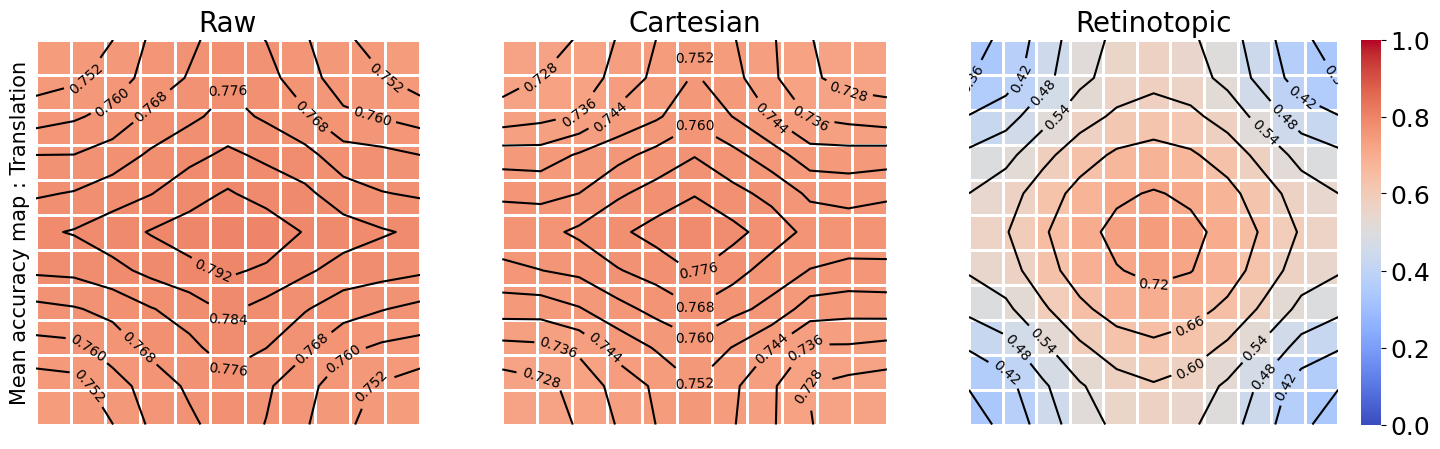

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap='coolwarm', vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'{title_mod}', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
axs[0].set_ylabel('Mean accuracy map : Translation', size = 15)
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_map_Imagenet_paper')

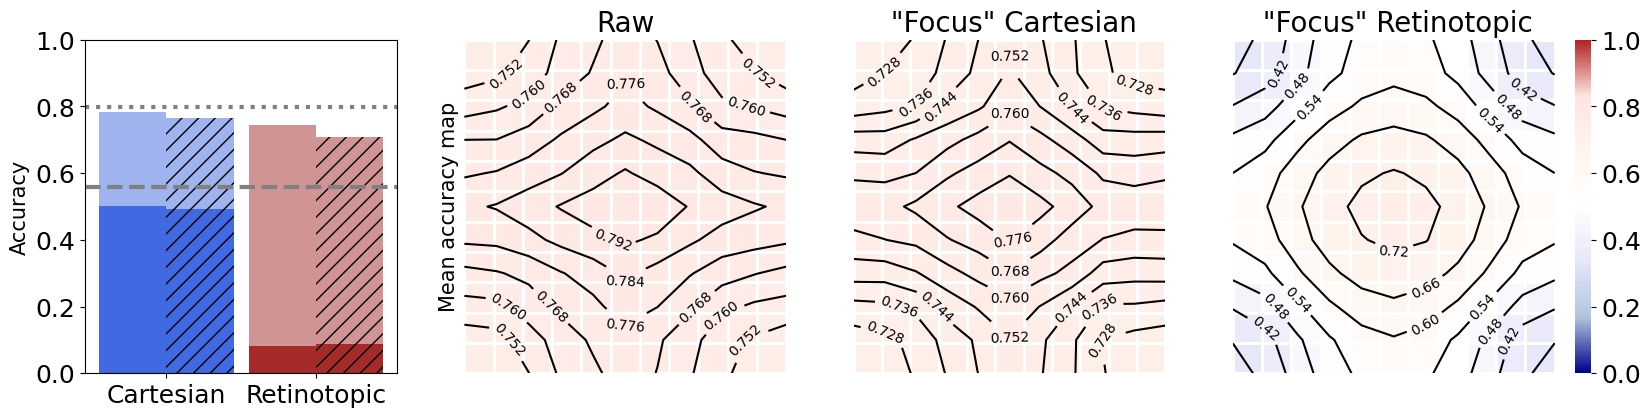

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
fig, axs = plt.subplots(1, 4, sharex=False, sharey=False, figsize=(fig_width, fig_width/4.61803), width_ratios=[1.55, 1.6, 1.55, 2])

model_name = 'resnet101'
#colors_cart = ['lightsteelblue', 'brown']
colors = ['royalblue', 'brown']
acc_full_ret_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_min']

acc_full_ret = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_zero']

acc_full_lin_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_min']

acc_full_lin = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_zero']

acc_bbox_ret_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_min']

acc_bbox_ret = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_zero']

acc_bbox_lin_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_min']

acc_bbox_lin = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_zero']

acc_notrain = acc_plot[get_filename(data_cache, datetag, 'raw', model_name, False) + '_zero']

acc_notrain_min = acc_plot[get_filename(data_cache, datetag, 'raw', model_name, False) + '_min']


type_mod = ("Cartesian", "Retinotopic")
data_means = {
    'full image': (acc_full_lin, acc_full_ret),
    'bounding box': (acc_bbox_lin, acc_bbox_ret ),

}

x = np.arange(len(type_mod))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0
hatchs = [None, "//"]

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, label=attribute, alpha =.5, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

data_means = {
    'full image': (acc_full_lin_min, acc_full_ret_min),
    'bounding box': (acc_bbox_lin_min, acc_bbox_ret_min )
}
multiplier = 0

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

axs[0].axhline(y=0.799, c='gray', ls='dotted', lw=3, label='before attack')
axs[0].axhline(y=0.559, c='gray', ls='--', lw=3, label='after attack')

axs[0].set_xticks(x + width/2, type_mod)
axs[0].set_ylabel('Accuracy', font=font, fontsize=15)
axs[0].legend(loc='upper left', ncols=2, fontsize=15)
axs[0].set_ylim(0, 1)
legend = axs[0].legend()
legend.remove()

i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model+1]
    title_mod = all_titles[i_model] if 'aw' in all_titles[i_model] else """ "Focus" """ + all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'{title_mod}', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
axs[1].set_ylabel('Mean accuracy map', size = 15)
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_accuracy_translation_paper')